Hermite Curve

In [1]:
import torch
import matplotlib.pyplot as plt

The curve starts at $P_0$ and ends at $P_1$. The vectors $T_0$ and $T_1$ dictate the direction and "velocity" of the curve as it leaves the start and arrives at the finish.

In [2]:
# Geometry vectors
P0 = torch.tensor([0.0, 0.0])
P1 = torch.tensor([5.0, 3.0])
T0 = torch.tensor([3.0, 5.0])
T1 = torch.tensor([3.0, -4.0])

In spline mathematics, the geometry matrix $G$ collects these four vectors into a single structure. While 3D modeling often uses matrices for translation or rotation, the geometry matrix in Hermite interpolation serves as the coefficient set for the basis functions.The state of the curve at any point $t$ is calculated by the product of the basis functions, the Hermite matrix, and this geometry matrix:$$P(t) = \begin{bmatrix} t^3 & t^2 & t & 1 \end{bmatrix} M_H G$$Where $G$ represents:$$G = \begin{bmatrix} P_0 \\ P_1 \\ T_0 \\ T_1 \end{bmatrix}$$This layout allows the code to solve for any point on the 2D plane by treating the $x$ and $y$ components as independent cubic functions of $t$.

In [3]:
# Stack into geometry matrix (4x2)
G = torch.stack([P0, P1, T0, T1])

# The Geometry Matrix

The geometry matrix $G$ consolidates the four boundary conditions into a single $4 \times 2$ tensor. This structure organizes the spatial "ingredients" of the curve so they can be processed by the basis functions.

Each row in $G$ corresponds to a specific geometric constraint:$P_0$: Starting position$P_1$: Ending position$T_0$: Tangent at the start$T_1$: Tangent at the endThe number of columns represents the spatial dimensions. Because we're working in 2D, the matrix has two columns for $x$ and $y$. If you move to 3D, the matrix expands to $4 \times 3$ 

In [4]:
# Hermite basis matrix (4x4)
M = torch.tensor([
    [ 2., -2.,  1.,  1.],
    [-3.,  3., -2., -1.],
    [ 0.,  0.,  1.,  0.],
    [ 1.,  0.,  0.,  0.]
])

### The Hermite Basis Matrix

The basis matrix $M$ is a constant $4 \times 4$ tensor. It defines the mathematical relationship between the time parameter $t$ and the geometric constraints $G$.

In CAD and geometric modeling, $M$ dictates how the control points generate the final shape. Each column of this matrix corresponds to one of the four Hermite blending functions. When you multiply the parameter vector $T = [t^3, t^2, t, 1]$ by $M$, you calculate the weight of $P_0, P_1, T_0,$ and $T_1$ for that specific moment in time.The values in $M$ are derived from the required boundary conditions:At $t=0$, the curve must be at $P_0$.At $t=1$, the curve must be at $P_1$.The derivative at $t=0$ must match $T_0$.The derivative at $t=1$ must match $T_1$.

In [5]:
# t values
t_vals = torch.linspace(0, 1, 100)

In [6]:
curve_points = []

In [7]:
for t in t_vals:
    T = torch.tensor([t**3, t**2, t, 1.0])  # 1x4
    point = T @ M @ G                      # (1x4)(4x4)(4x2) -> 1x2
    curve_points.append(point)


### Generating Curve Points

To generate the actual points along the spline, you iterate through a range of $t$ values from $0$ to $1$. Each step calculates a parameter vector $T$ that represents the cubic powers of time.

The operation $T \cdot M$ produces the four Hermite blending functions, often denoted as $h_0(t), h_1(t), h_2(t),$ and $h_3(t)$. These functions act as weights. Multiplying the result by $G$ sums up the contributions of $P_0, P_1, T_0,$ and $T_1$ based on those weights.

In [8]:
curve = torch.stack(curve_points)

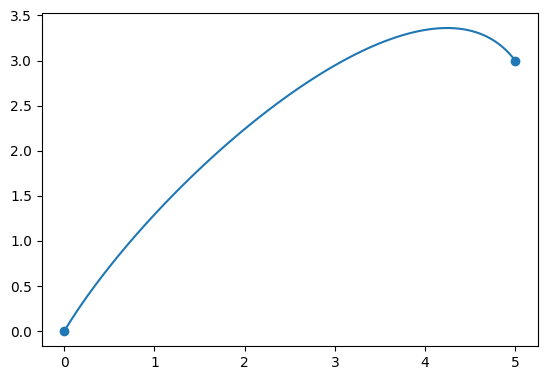

In [9]:
# Plot
plt.plot(curve[:,0].numpy(), curve[:,1].numpy())
plt.scatter([P0[0], P1[0]], [P0[1], P1[1]])
plt.gca().set_aspect('equal', 'box')
plt.show()